# Customer Churn Prediction and Retention Analysis Using Machine

## Jiahua Liu & Yifan Yu
## Deadline Dodgers

## 1. Executive Summary

**1.1 Decisions to be impacted**

This project supports three key managerial decisions in customer retention management:

(1) Precision Targeting Decision

The predictive model ranks customers by churn probability. Applying Pareto Analysis, we focus on the small proportion of high-risk customers who account for the majority of potential revenue loss. By targeting only this critical segment, the company can allocate retention resources more efficiently, maximize ROI, and avoid unnecessary incentives for low-risk customers.

(2) Intervention Timing Decision

Moving beyond simple contract tracking, we implement a lifecycle-value segmentation approach that integrates tenure, usage intensity, and spending. This allows for strategic intervention timing—targeting high-value customers at their most vulnerable lifecycle stages to maximize both retention impact and resource efficiency.

(3) Risk Threshold Decision

The model enables the establishment of an economically optimized risk threshold for intervention. Instead of relying on arbitrary percentages or intuition, retention actions are guided by cost-sensitive evaluation and quantified churn risk.

**1.2 Business value**

The primary business value of this project lies in revenue preservation and cost optimization.

• Revenue Protection:

By proactively identifying customers at risk of churn, the company can prevent revenue loss and maximize Customer Lifetime Value (CLV).

• Marketing ROI Improvement:

Targeted interventions reduce unnecessary spending on low-risk customers, increasing the return on investment of retention campaigns.

• Strategic Resource Allocation:

Rather than reacting to churn after it occurs, this model enables proactive strategy, shifting retention management from a reactive cost center to a value-generating system.

• Long-Term Competitive Stability:

Reducing customer attrition strengthens market position and stabilizes recurring revenue streams in a saturated telecom market.

**1.3 Data assets**

The project utilizes the Telco Customer Churn dataset, publicly available on Kaggle and originally sourced from IBM. The dataset contains 7,043 customer records and provides a comprehensive view of customer profiles across three major dimensions: demographic characteristics (e.g., gender and senior status), service subscription details (e.g., internet type and streaming services), and account and financial information (e.g., contract type and monthly charges). This multi-dimensional structure allows for a holistic understanding of customer behavior within a subscription-based telecom environment.
The integration of behavioral and financial variables enables the identification of key churn drivers, the estimation of individual-level churn probability, and the simulation of cost-benefit scenarios for targeted retention strategies. Because the dataset is structured, clean, and clearly labeled with a binary churn outcome, it is well suited for supervised machine learning modeling and decision-oriented business evaluation.


## 2. Data Preprocessing

In [3]:
#input dataset
import pandas as pd

df = pd.read_excel("Telco_customer_churn.xlsx")

## 2.1 Data Description -- summary of datasets and visualizations of input data

**2.1.1 Dataset Overview**

The dataset contains 7,043 customer observations and 33 variables. Among these variables, churn outcome information is recorded in two forms: categorical variable (Churn Label: Yes/No) and its numerical representation (Churn Value: 1 = churn/Yes, 0 = retained/No).  

In [5]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [8]:
df.shape

(7043, 33)

These variables capture whether a customer discontinued service in the previous month. The remaining variables serve as explanatory features and can be categorized by data type and business domain, as summarized in Table 1 and Table 2. This structure provides a comprehensive representation of customer demographics, service usage, and financial characteristics.

In [9]:
#table 1.Variable Classification by Data Type

# identify variables
numerical_vars = df.select_dtypes(include=['number']).columns.tolist()
categorical_vars = df.select_dtypes(exclude=['number']).columns.tolist()

# combine into table
table_type = pd.DataFrame({
    "Data_Type": ["Categorical", "Numerical"],
    "Variables": [
        ", ".join(categorical_vars),
        ", ".join(numerical_vars)
    ]
})

# display
pd.set_option('display.max_colwidth', None)
table_type.style.set_properties(**{'text-align': 'left'})

,Data_Type,Variables
0,Categorical,"CustomerID, Country, State, City, Lat Long, Gender, Senior Citizen, Partner, Dependents, Phone Service, Multiple Lines, Internet Service, Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies, Contract, Paperless Billing, Payment Method, Total Charges, Churn Label, Churn Reason"
1,Numerical,"Count, Zip Code, Latitude, Longitude, Tenure Months, Monthly Charges, Churn Value, Churn Score, CLTV"


In [10]:
#table 2. Variable Classification by Business Domain
# define variable groups
demographic_vars = ["Gender","SeniorCitizen","Partner","Dependents"]

service_vars = [
    "PhoneService","MultipleLines","InternetService",
    "OnlineSecurity","OnlineBackup","DeviceProtection",
    "TechSupport","StreamingTV","StreamingMovies"
]

account_fin_vars = [
    "TenureMonths","Contract","PaperlessBilling",
    "PaymentMethod","MonthlyCharges","TotalCharges","CLTV"
]

# create table
table_domain = pd.DataFrame({
    "Category": [
        "Demographic Characteristics",
        "Service Subscription Details",
        "Account and Financial Information"
    ],
    "Variables": [
        ", ".join(demographic_vars),
        ", ".join(service_vars),
        ", ".join(account_fin_vars)
    ]
})

# display
pd.set_option('display.max_colwidth', None)
table_domain.style.set_properties(**{'text-align': 'left'})

,Category,Variables
0,Demographic Characteristics,"Gender, SeniorCitizen, Partner, Dependents"
1,Service Subscription Details,"PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies"
2,Account and Financial Information,"TenureMonths, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, CLTV"


**2.1.2 Target Variable Distribution -- Churn Value**

As shown in Table 3, the distribution of the target variable reveals a moderate class imbalance, with churn customers representing approximately 26.5% of the total sample. While not severely skewed, this imbalance warrants careful model evaluation using class-sensitive performance metrics.

In [11]:
target_counts = df["Churn Value"].value_counts(dropna=False).sort_index()
target_props = df["Churn Value"].value_counts(normalize=True, dropna=False).sort_index()

target_dist = pd.DataFrame({
    "ChurnValue": target_counts.index,
    "Count": target_counts.values,
    "Proportion": target_props.values
})

target_dist

,ChurnValue,Count,Proportion
0,0,5174,0.73463
1,1,1869,0.26537


**2.1.3 Numerical Feature Analysis**

The numerical variables display varying levels of dispersion and scale. Notably, Total Charges and CLTV exhibit substantially larger ranges compared to other variables, suggesting potential right-skewness and scale differences. Such disparities in magnitude may require normalization or standardization prior to modeling. Additionally, the broad distribution of Tenure Months indicates heterogeneity in customer retention behavior, which may be strongly associated with churn outcomes. (Table 4)

In [12]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# numerical feature analysis
num_vars_clean = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Churn Score",
    "CLTV"
]

desc_table = df[num_vars_clean].agg(["mean", "std", "min", "max"]).T.reset_index()
desc_table.columns = ["Variable", "Mean", "SD", "Min", "Max"]

desc_table = desc_table.round(2)

desc_table

,Variable,Mean,SD,Min,Max
0,Tenure Months,32.37,24.56,0.00,72.00
1,Monthly Charges,64.76,30.09,18.25,118.75
2,Total Charges,2283.30,2266.77,18.80,8684.80
3,Churn Score,58.70,21.53,5.00,100.00
4,CLTV,4400.30,1183.06,2003.00,6500.00


**2.1.4 Categorical Feature Analysis**

The dataset contains several categorical variables describing customer demographics, services, and billing characteristics. Examples include Gender, Partner, Dependents, Contract Type, Internet Service, and Payment Method. While many categorical variables are available, this analysis focuses on three key variables: Contract Type, Internet Service, and Payment Method.

These variables were selected because they are directly related to customer service structure and billing behavior, which are known to strongly influence customer churn in telecommunications services. Contract type reflects the level of commitment between the customer and the company, internet service represents the type of service provided, and payment method describes how customers interact with the billing system. These factors are often associated with customer satisfaction and switching behavior.


The visualizations show that contract type has a clear relationship with churn behavior. Customers with month-to-month contracts exhibit significantly higher churn rates compared to customers with one-year or two-year contracts, indicating that longer contractual commitments may help reduce churn.

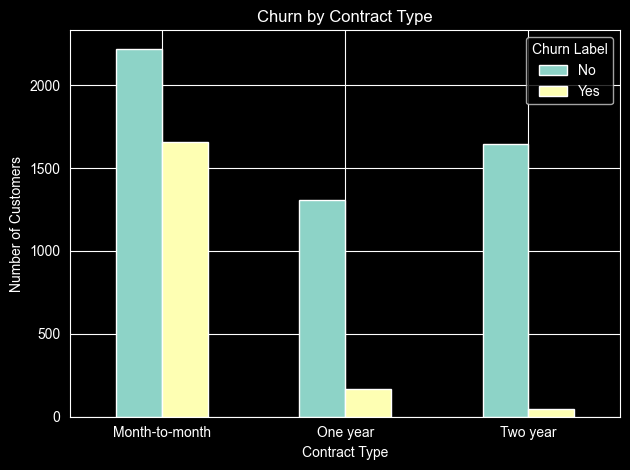

In [13]:
#=================Contract vs Churn==================
import pandas as pd
import matplotlib.pyplot as plt
df_clean = df.copy()
df_clean["Total Charges"] = pd.to_numeric(df_clean["Total Charges"], errors="coerce")
contract_churn = pd.crosstab(df_clean["Contract"], df_clean["Churn Label"])

contract_churn.plot(kind="bar")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn Label")
plt.tight_layout()
plt.show()


For internet service, customers using fiber optic services appear to have a higher churn proportion compared to DSL or customers without internet service, which may suggest differences in service cost, expectations, or service quality.


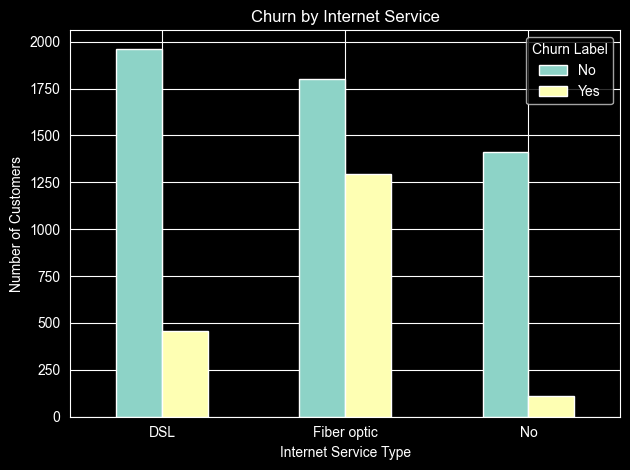

In [14]:
#=================Internet Service vs Churn==================
internet_churn = pd.crosstab(df_clean["Internet Service"], df_clean["Churn Label"])

internet_churn.plot(kind="bar")
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn Label")
plt.tight_layout()
plt.show()

In terms of payment method, customers who use electronic check payments show noticeably higher churn rates compared to those using automatic bank transfer or credit card payments, suggesting that automated payment methods may be associated with higher customer retention.

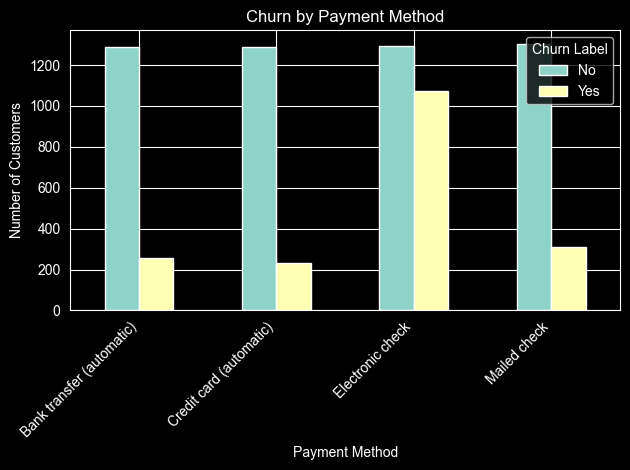

In [15]:
#=================Payment Method vs Churn=================
payment_churn = pd.crosstab(df_clean["Payment Method"], df_clean["Churn Label"])

payment_churn.plot(kind="bar")
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Churn Label")
plt.tight_layout()
plt.show()

Overall, these three categorical variables provide meaningful insights into customer churn behavior and are therefore selected as representative features for categorical feature analysis.

**2.1.5 Bivariate Relationships with Churn**

Variable Selection
Although the dataset contains many variables, not all of them are suitable for analyzing the relationship with customer churn. Several variables such as CustomerID, Country, State, City, Zip Code, Latitude, and Longitude mainly serve as identifiers or geographic information and do not directly reflect customer behavior or service usage. Therefore, they are unlikely to provide meaningful insights into churn behavior.

Additionally, some variables such as Count contain no variation across observations, while Churn Reason is only recorded for customers who have already churned, making it unsuitable as a predictor for churn analysis.

Based on the earlier univariate analysis, a subset of variables that are more closely related to customer engagement, service usage, and billing characteristics was selected for further investigation. These variables include **Tenure Months, Monthly Charges, Total Charges, Contract Type, Internet Service, and Payment Method**, which are commonly considered key factors influencing customer retention in telecommunications services.


**Numerical Variables vs Churn**

**a. Tenure Months vs Churn**

The boxplot shows a clear difference in tenure between churned and non-churned customers. Customers who did not churn generally have longer tenure periods, while customers who churned tend to have much shorter tenure durations. The median tenure for churned customers is significantly lower than that of non-churned customers. This suggests that newer customers are more likely to churn, indicating that customer retention strategies may be particularly important during the early stages of the customer lifecycle.


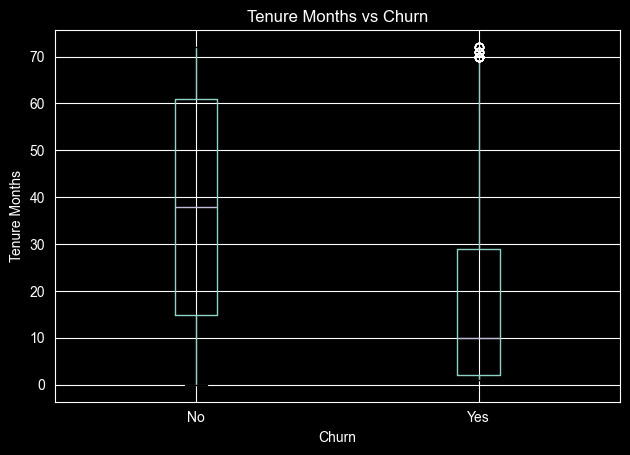

In [16]:
# Tenure Months vs Churn
df_clean.boxplot(column="Tenure Months", by="Churn Label")
plt.title("Tenure Months vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure Months")
plt.tight_layout()
plt.show()

**b. Monthly Charges vs Churn**

The distribution of monthly charges indicates that customers who churn tend to have higher monthly charges on average compared to those who remain with the service. The median monthly charge for churned customers is noticeably higher. This suggests that higher service costs may increase the likelihood of churn, possibly because customers perceive the service as less cost-effective compared to alternatives.


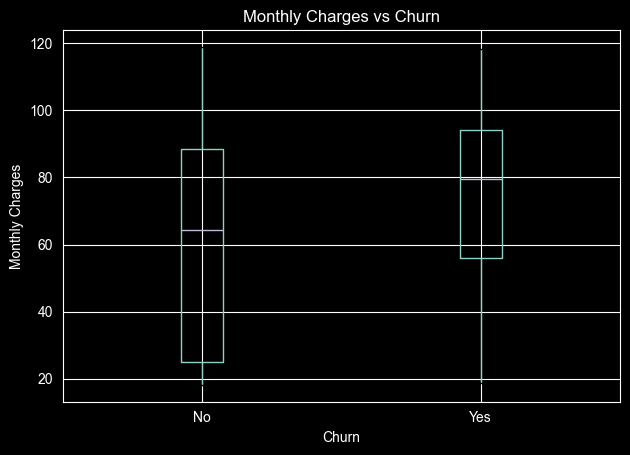

In [17]:
# Monthly Charges vs Churn
df_clean.boxplot(column="Monthly Charges", by="Churn Label")
plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

**c. Total Charges vs Churn**

The total charges distribution shows that non-churned customers typically accumulate higher total charges over time, which is expected since they tend to remain with the service for longer periods. In contrast, churned customers usually have lower total charges, reflecting their shorter tenure with the company. This pattern further supports the observation that customers who stay longer contribute more total revenue and are less likely to churn.


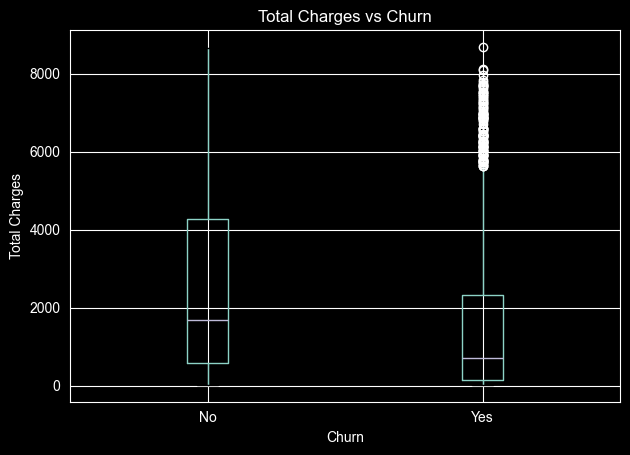

In [18]:
# Total Charges vs Churn
df_clean.boxplot(column="Total Charges", by="Churn Label")
plt.title("Total Charges vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.tight_layout()
plt.show()

**Categorical Variables vs Churn**

**a. Contract Type vs Churn Rate**

The analysis of contract type reveals a strong relationship with churn behavior. Customers with month-to-month contracts exhibit the highest churn rate, significantly higher than those with one-year or two-year contracts. In contrast, customers with longer-term contracts have much lower churn rates. This suggests that longer contractual commitments help improve customer retention, as customers are less likely to leave before their contract period ends.


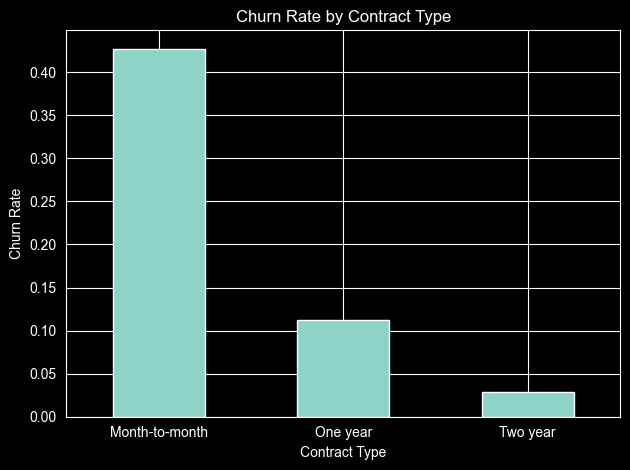

In [19]:
# Contract vs Churn Rate
contract_rate = pd.crosstab(df_clean["Contract"], df_clean["Churn Label"], normalize="index")

contract_rate.iloc[:, 1].plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**b. Internet Service vs Churn Rate**

Among the different internet service types, customers using fiber optic services show the highest churn rate, while DSL users have a moderate churn rate and customers without internet service show the lowest churn rate. This pattern may indicate differences in service expectations, pricing, or service quality, which could influence customer satisfaction and retention.


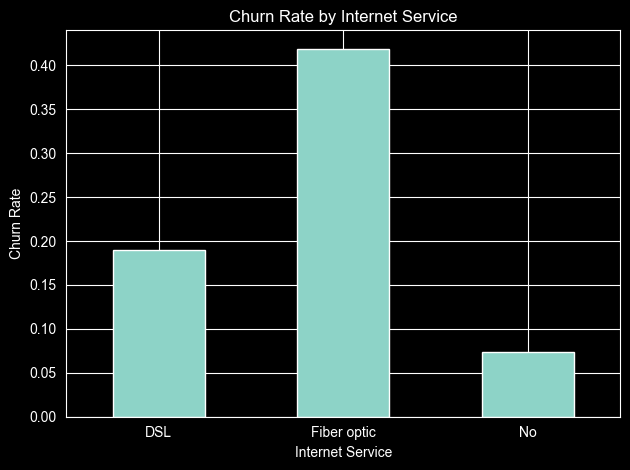

In [20]:
# Internet Service vs Churn Rate
internet_rate = pd.crosstab(df_clean["Internet Service"], df_clean["Churn Label"], normalize="index")

internet_rate.iloc[:, 1].plot(kind="bar")
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**c. Payment Method vs Churn Rate**
    
The churn rate also varies across payment methods. Customers who pay using electronic check exhibit the highest churn rate, whereas those using automatic payment methods such as bank transfer or credit card tend to have lower churn rates. This suggests that automatic payment methods may be associated with stronger customer commitment and more stable service usage.


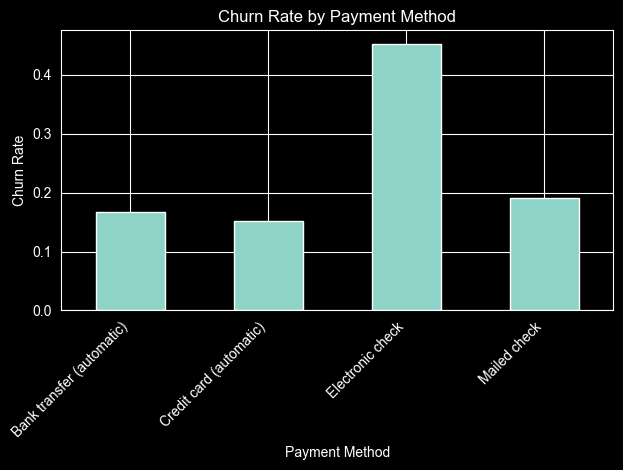

In [21]:
# Payment Method vs Churn Rate
payment_rate = pd.crosstab(df_clean["Payment Method"], df_clean["Churn Label"], normalize="index")

payment_rate.iloc[:, 1].plot(kind="bar")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Overall, the bivariate analysis indicates that both customer tenure and billing characteristics are strongly associated with churn behavior. Customers who are newer, pay higher monthly charges, use month-to-month contracts, subscribe to fiber optic services, or use electronic check payment methods appear to have a higher likelihood of churning. These findings provide useful insights for identifying high-risk customers and developing targeted retention strategies.


## 2.2 Introduce the data cleaning metrics you used in the process and outlier detection

**2.2.1 Identify outlier and missing value**

**a. Outlier Detection**

Outlier detection was conducted on the *Total Charges* variable. Although the dataset contains multiple variables, many of them are categorical (e.g., Gender, Contract, Internet Service), for which outlier detection is not applicable. Among the numerical variables, *Total Charges* was selected because it represents the total amount paid by a customer over their service period, making it an important indicator of customer spending behavior. In addition, this variable typically exhibits a wider range compared to other numerical features and is therefore more likely to contain extreme values.

To identify potential outliers, three methods were applied: the IQR method, Z-score method, and boxplot visualization. Based on the Python analysis, no significant outliers were detected in the *Total Charges* variable using either the IQR or Z-score methods. This result is further supported by the boxplot, which does not display any clear extreme observations.

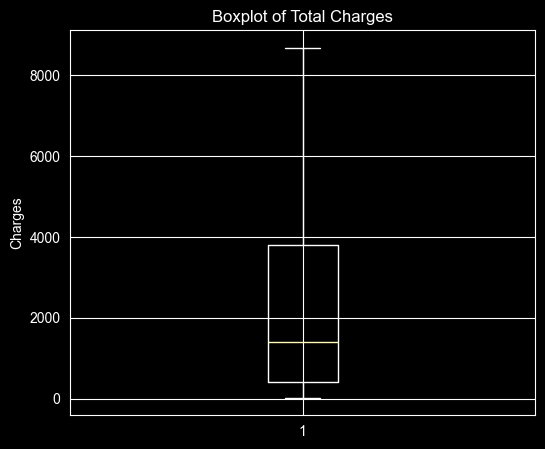

Q1: 401.4
Q3: 3794.975
IQR: 3393.575
Lower bound: -4688.9625
Upper bound: 8885.3375
Total Charges outlier count: 0


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tc = pd.to_numeric(df["Total Charges"], errors="coerce")
tc_clean = tc.dropna()

#======================= IQR Method =======================

# Boxplot
plt.figure(figsize=(6, 5))
plt.boxplot(tc_clean)
plt.title("Boxplot of Total Charges")
plt.ylabel("Charges")
plt.show()

df["Total_Charges_log"] = np.log(tc + 1)

Q1 = tc_clean.quantile(0.25, interpolation='midpoint')
Q3 = tc_clean.quantile(0.75, interpolation='midpoint')

IQR_value = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR_value
upper_bound = Q3 + 1.5 * IQR_value

outliers_TotalCharges = tc_clean[
    (tc_clean < lower_bound) | (tc_clean > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR_value)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Total Charges outlier count:", len(outliers_TotalCharges))

In [23]:
#=======================Z-score Method=======================
x = df["Total Charges"]
x = pd.to_numeric(df["Total Charges"], errors='coerce')
z_scores = (x - x.mean()) / x.std()

outliers_z = x[z_scores.abs() > 3]

print("Z-score outliers:", len(outliers_z.dropna()))

Z-score outliers: 0


In [24]:
#=======================Boxplot Method=======================
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors='coerce')
Q1_box = df["Total Charges"].quantile(0.25)
Q3_box = df["Total Charges"].quantile(0.75)
IQR_box = Q3_box - Q1_box

lower_box = Q1_box - 1.5 * IQR_box
upper_box = Q3_box + 1.5 * IQR_box

outliers_box = df["Total Charges"][
    (df["Total Charges"] < lower_box) | (df["Total Charges"] > upper_box)
]

print("Boxplot outliers:", len(outliers_box.dropna()))

Boxplot outliers: 0


The absence of detected outliers suggests that the distribution of *Total Charges* is relatively well-behaved, and high values observed in the dataset likely reflect genuine customer spending patterns rather than data errors. Therefore, no observations were removed, and the variable was retained in its original form for subsequent analysis.

**multivariance outlier detection**

Multivariate outlier detection was conducted using Tenure Months, Monthly Charges, Total Charges, and CLTV, as these variables are continuous and jointly capture the core structure of customer behavior and value. The selection of these variables is grounded in both statistical and business considerations. From a statistical perspective, Mahalanobis distance requires continuous numerical variables in order to estimate the mean vector and covariance matrix, which makes categorical variables such as gender, contract type, and payment method unsuitable for this method. More importantly, these selected variables exhibit strong interdependence. Tenure and monthly charges together determine total charges, while all three contribute to the estimation of customer lifetime value. This interconnected structure allows the model to identify not only extreme values in individual variables, but also unusual combinations that deviate from the expected relationships among variables. In this sense, the analysis focuses on detecting abnormal patterns rather than isolated extreme observations. Using Mahalanobis distance, each observation’s distance from the multivariate center of the distribution was computed while accounting for correlations among variables.

In [25]:
import pandas as pd
import numpy as np
from scipy.stats import chi2
from sklearn.preprocessing import StandardScaler

cols = ["Tenure Months", "Monthly Charges", "Total Charges", "CLTV"]
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

data = df[cols].dropna().copy()

#standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

mean_vec = np.mean(X_scaled, axis=0)
cov_matrix = np.cov(X_scaled, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

#calculate Mahalanobis distance
diff = X_scaled - mean_vec
md_squared = np.sum(diff @ inv_cov_matrix * diff, axis=1)
md = np.sqrt(md_squared)

threshold = np.sqrt(chi2.ppf(0.99, df=len(cols)))

#detect outlier
data["Mahalanobis_Distance"] = md
data["Outlier"] = data["Mahalanobis_Distance"] > threshold

result = df.loc[data.index].copy()
result["Mahalanobis_Distance"] = data["Mahalanobis_Distance"]
result["Outlier"] = data["Outlier"]

print("Threshold:", threshold)
print("Number of outliers:", result["Outlier"].sum())
print(result[result["Outlier"]].head())

result.to_excel("telco_multivariate_outliers.xlsx", index=False)

Threshold: 3.6437211935036444
Number of outliers: 8
      CustomerID  Count        Country       State           City  Zip Code  \
2565  5787-KXGIY      1  United States  California      Palo Alto     94303   
2611  2545-LXYVJ      1  United States  California    Suisun City     94585   
2812  4821-WQOYN      1  United States  California   Little River     95456   
3135  0404-AHASP      1  United States  California  Beverly Hills     90212   
3211  1927-QEWMY      1  United States  California        Arcadia     91007   

                    Lat Long   Latitude   Longitude  Gender  ...  \
2565   37.45809, -122.115398  37.458090 -122.115398    Male  ...   
2611  38.197907, -122.017258  38.197907 -122.017258    Male  ...   
2812   39.245911, -123.77214  39.245911 -123.772140  Female  ...   
3135  34.062095, -118.401508  34.062095 -118.401508    Male  ...   
3211  34.128284, -118.047732  34.128284 -118.047732  Female  ...   

     Monthly Charges Total Charges Churn Label  Churn Value Chur

A threshold was determined based on the chi-square distribution at the 99% confidence level, resulting in a cutoff value of 3.6437. Observations with a Mahalanobis distance exceeding this threshold were classified as multivariate outliers. The results show that only eight observations in the dataset were identified as outliers, indicating that the overall data distribution is relatively well-behaved and does not contain a large number of anomalous cases.

A closer examination of these outliers reveals a consistent and interpretable pattern. These customers tend to have very low monthly charges, approximately around 20, while simultaneously exhibiting relatively high total charges and CLTV values. This combination deviates from the general trend observed in the dataset, where higher total charges are typically associated with higher monthly spending. The presence of low monthly charges alongside substantial accumulated charges suggests that these customers have maintained their subscriptions over a long period of time, resulting in high total contributions despite their low spending intensity. Furthermore, all identified outliers are non-churn customers, indicating that they are highly stable and retained over time. From a business perspective, these outliers likely represent long-tenure customers on legacy low-cost plans. As they reflect meaningful customer behavior rather than data errors, they were retained for further analysis.

**b. Identify Missing Value**

A missing value analysis was conducted to evaluate the completeness of the dataset. The number and percentage of missing values were calculated for each variable.

The results indicate that most variables in the dataset do not contain missing values, suggesting that the dataset is largely complete. However, two variables contain missing observations: Total Charges and Churn Reason.

The variable Total Charges contains 11 missing values, accounting for approximately 0.16% of the dataset. This is a very small proportion and is likely due to newly subscribed customers whose total charges have not yet been accumulated. Since the number of missing observations is negligible, these records can be safely removed without significantly affecting the dataset.

In contrast, the variable Churn Reason contains 5,174 missing values, representing approximately 73.46% of the dataset. This occurs because the churn reason is only recorded for customers who have actually churned, while customers who remain with the company do not have an associated churn reason. Therefore, these missing values are structural missing values rather than data quality issues.


In [26]:
missing_summary = pd.DataFrame({
    "Variable": df.columns,
    "Missing_Count": df.isna().sum().values,
    "Missing_Percentage": (df.isna().sum().values / len(df)) * 100
})

missing_summary = missing_summary.round({"Missing_Percentage": 2})

missing_summary

,Variable,Missing_Count,Missing_Percentage
0,CustomerID,0,0.00
1,Count,0,0.00
2,Country,0,0.00
3,State,0,0.00
4,City,0,0.00
5,Zip Code,0,0.00
6,Lat Long,0,0.00
7,Latitude,0,0.00
8,Longitude,0,0.00
9,Gender,0,0.00


Overall, the dataset contains minimal missing values in key variables, and appropriate handling strategies will be applied to ensure data quality in subsequent analyses.

**2.2.2 Handle outlier and missing value**


**a. Outlier treatment**

Outlier detection using the IQR and Z-score methods did not identify any significant outliers in the *Total Charges* variable. This finding is consistent with the boxplot visualization, which does not display any clear extreme observations.

Although the variable exhibits a relatively wide range, the observed high values are likely to reflect genuine customer behavior, particularly for long-term or high-spending customers, rather than data errors. Given that *Total Charges* represents the cumulative amount paid over a customer's service period, larger values are expected and do not necessarily indicate anomalies.

Therefore, no outlier treatment was required, and all observations were retained in the dataset for subsequent analysis.


**b. missing value treatment**

To address these missing values, median imputation was applied. The median was chosen instead of the mean because the Total Charges variable is right-skewed and may contain relatively large values from long-term or high-spending customers. In such cases, the mean can be influenced by extreme values, while the median provides a more robust measure of central tendency.

By replacing the missing values with the median of the observed data, the integrity of the dataset is preserved without introducing significant bias. This approach ensures that the imputed values remain representative of the typical customer spending level while minimizing the impact of potential outliers.


In [27]:
df_clean = df.copy()

# Replace missing values in Total Charges with median
df_clean["Total Charges"] = df_clean["Total Charges"].fillna(
    df_clean["Total Charges"].median()
)

# Check missing values again
df_clean.isna().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
Total_Charges_log      11
dtype: int64

## 2.3 Multicollinearity Analysis

**2.3.1 Correlation Heatmap**

The heatmap displays statistically significant correlations among the numerical variables, with both correlation coefficients and corresponding p-values reported. All relationships shown satisfy the significance threshold (p < 0.05), and the majority exhibit extremely small p-values (p < 0.001), indicating that these correlations are highly statistically significant and unlikely to have occurred by chance.

✅ 清洗并剔除无关变量后的数据维度: (7032, 6)


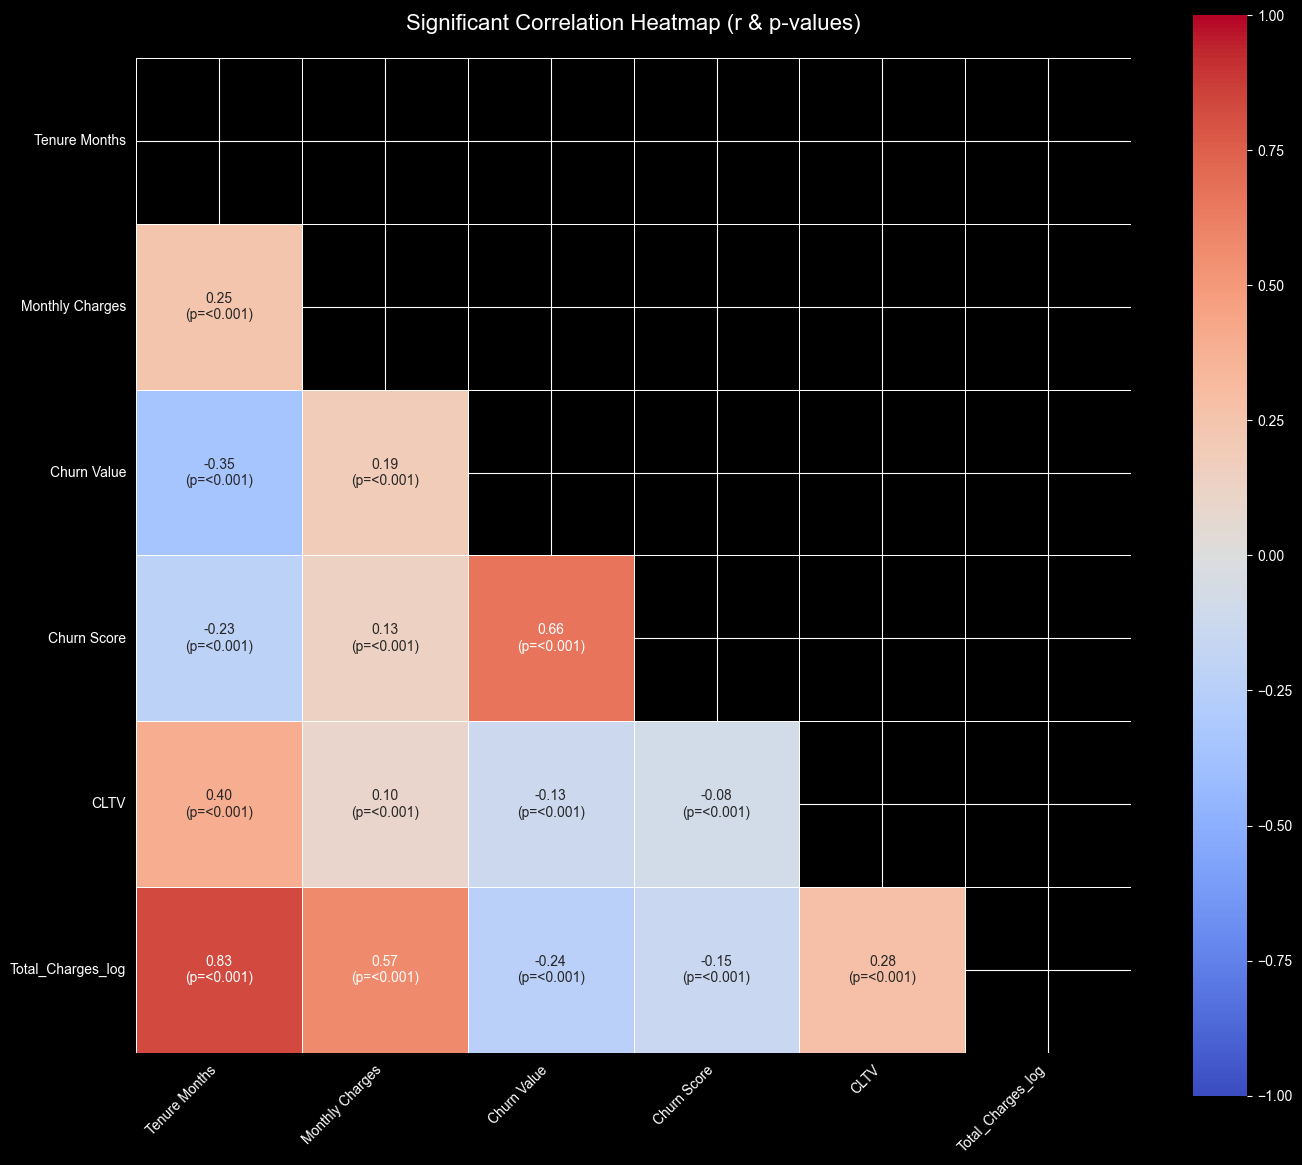

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# ===============================
# Step 1: Prepare data
# ===============================
df_clean = df.copy()

if "Total Charges" in df_clean.columns:
    df_clean["Total Charges"] = pd.to_numeric(df_clean["Total Charges"], errors="coerce")

num_df = df_clean.select_dtypes(include=["number"]).dropna()

num_df = num_df.loc[:, num_df.nunique() > 1]


cols_to_drop = ["Zip Code", "Latitude", "Longitude", "Total Charges"]

num_df = num_df.drop(columns=[col for col in cols_to_drop if col in num_df.columns])

print(f"✅ 清洗并剔除无关变量后的数据维度: {num_df.shape}")

# ===============================
# Step 2 & 3: Compute Correlation & P-value Matrix
# ===============================
corr_matrix = num_df.corr()

p_matrix = pd.DataFrame(index=corr_matrix.index, columns=corr_matrix.columns, dtype=float)

for col1 in num_df.columns:
    for col2 in num_df.columns:
        if col1 == col2:
            p_matrix.loc[col1, col2] = 1.0
        else:
            _, p = pearsonr(num_df[col1], num_df[col2])
            p_matrix.loc[col1, col2] = p

# ===============================
# Step 4: Create annotation matrix
# ===============================
annot_matrix = pd.DataFrame("", index=corr_matrix.index, columns=corr_matrix.columns, dtype=str)

for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        r = corr_matrix.loc[col1, col2]
        p = p_matrix.loc[col1, col2]

        if col1 == col2:
            annot_matrix.loc[col1, col2] = ""
        else:
            p_text = "<0.001" if p < 0.001 else f"{p:.3f}"
            annot_matrix.loc[col1, col2] = f"{r:.2f}\n(p={p_text})"

# ===============================
# Step 5: Create mask
# ===============================
alpha = 0.05

mask = p_matrix > alpha

upper_tri_mask = np.triu(np.ones_like(mask, dtype=bool), k=0)

final_mask = mask | upper_tri_mask

# ===============================
# Step 6: Plot heatmap
# ===============================
plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar=True,
    mask=final_mask,
    vmin=-1, vmax=1
)

plt.title("Significant Correlation Heatmap (r & p-values)", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Several strong and meaningful patterns can be identified. Geographic variables, including Latitude and Longitude, exhibit very strong correlations (r = 0.90 and r = -0.88, respectively, both p < 0.001), reflecting their shared representation of spatial location. This suggests a high degree of redundancy among geographic features.

From a behavioral perspective, Total Charges is strongly correlated with Tenure Months (r = 0.83, p < 0.001) and moderately correlated with Monthly Charges (r = 0.65, p < 0.001). These relationships are consistent with the underlying business logic, as cumulative charges are driven by both the duration of service and the level of monthly spending.

In terms of churn behavior, Tenure Months shows a negative correlation with Churn Value (r = -0.35, p < 0.001) and Churn Score (r = -0.23, p < 0.001), indicating that customers with longer tenure are less likely to churn. Additionally, Churn Value and Churn Score are strongly positively correlated (r = 0.66, p < 0.001), suggesting that the churn scoring system aligns well with actual churn outcomes.

Customer lifetime value (CLTV) is moderately associated with Tenure Months (r = 0.40, p < 0.001) and Total Charges (r = 0.34, p < 0.001), but only weakly correlated with Monthly Charges (r = 0.10, p < 0.001). This implies that long-term engagement contributes more significantly to customer value than short-term spending intensity.

Overall, the results demonstrate that the observed relationships are both strong in magnitude and statistically significant, reinforcing the reliability of the correlation structure and highlighting key behavioral and business patterns within the dataset.

**2.3.2 VIF**

To assess multicollinearity among the predictors, the Variance Inflation Factor (VIF) was calculated for all numerical variables after excluding the target variables.

In [29]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop(columns=["Churn Value", "Churn Label"], errors="ignore")
X_vif = X_vif.select_dtypes(include=[np.number])
X_vif = X_vif.dropna()
X_vif = X_vif.loc[:, X_vif.nunique() > 1]

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif = vif.sort_values(by="VIF", ascending=False)

print(vif)

             Feature          VIF
0           Zip Code  6873.740105
2          Longitude  6347.695631
1           Latitude   401.266542
8  Total_Charges_log   145.317798
3      Tenure Months    34.059120
4    Monthly Charges    30.606636
5      Total Charges    20.722291
7               CLTV    17.992623
6        Churn Score     9.450468


The initial VIF results revealed extremely high values for geographical variables, including Zip Code, Latitude, and Longitude, with VIF values exceeding 6000. This indicates severe multicollinearity, which is expected since these variables represent overlapping spatial information (i.e., geographic location).

To address this issue, these geographical variables were removed from the dataset. The VIF was then recalculated on the remaining variables.

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
X_new = X_vif.drop(columns=["Zip Code", "Latitude", "Longitude"], errors="ignore")

vif_new = pd.DataFrame()
vif_new["Feature"] = X_new.columns
vif_new["VIF"] = [
    variance_inflation_factor(X_new.values, i)
    for i in range(X_new.shape[1])
]

print(vif_new.sort_values(by="VIF", ascending=False))

             Feature        VIF
5  Total_Charges_log  59.656303
0      Tenure Months  29.722840
1    Monthly Charges  29.255326
2      Total Charges  20.475990
4               CLTV  13.565104
3        Churn Score   8.281456


After removal, the updated VIF results showed that all variables had values below 10.These results indicate that multicollinearity is within an acceptable range. Although CLTV exhibits a relatively higher VIF, this is expected as it is inherently related to other financial and behavioral variables (e.g., tenure and charges). Given its strong business relevance, it was retained in the model.


## 3. Model Selection

To evaluate and predict customer churn, three classification models were selected: Logistic Regression, Random Forest, and Gradient Boosting (including XGBoost).

Logistic Regression was chosen as a baseline model due to its simplicity, interpretability, and effectiveness for binary classification problems. It allows for clear interpretation of the relationship between predictors and the probability of churn, making it useful for understanding key factors influencing customer behavior.

Random Forest was included as a tree-based ensemble method that can capture nonlinear relationships and complex interactions among variables. It is robust to noise and overfitting due to its use of multiple decision trees and averaging, making it suitable for handling high-dimensional data with mixed feature types.

Gradient Boosting (e.g., XGBoost) was selected for its strong predictive performance. By sequentially building trees that focus on correcting previous errors, boosting methods are highly effective in capturing subtle patterns in the data and often achieve superior accuracy in classification tasks.

By comparing these three models, the analysis aims to balance interpretability and predictive performance, while identifying the most effective approach for customer churn prediction.

**3.1 Logistic regression**

Logistic Regression was selected as the baseline model in this study due to its simplicity, interpretability, and effectiveness in binary classification tasks. As a linear model, it allows for clear interpretation of how each feature influences the probability of customer churn, making it particularly suitable for initial modeling and benchmarking against more complex models such as Random Forest and XGBoost.

The target variable in this analysis is Churn Value, and the predictors include Tenure Months, Monthly Charges, Churn Score, and CLTV. These features capture key aspects of customer behavior, including customer longevity, spending patterns, and estimated customer value, all of which are expected to have strong relationships with churn behavior. To ensure numerical stability and improve model performance, feature standardization was applied so that all variables are on a comparable scale, which is important for Logistic Regression as it is sensitive to the magnitude of input features.

**Data Splitting and Preprocessing**

The dataset was first divided into a training set and a test set using an 80/20 split. Stratified sampling was applied to preserve the proportion of churn and non-churn customers in both subsets, ensuring a representative distribution for model training and evaluation. The test set was held out and not used during model selection, allowing for an unbiased assessment of the final model’s generalization performance.


In [7]:
#split training set and test set
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

y = df["Churn Value"]
X = df[["Tenure Months", "Monthly Charges", "Churn Score", "CLTV"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (5634, 4)
Test set size: (1409, 4)


**Cross-Validation on Training Set**

To evaluate the robustness of the model and avoid relying on a single data split, cross-validation was conducted on the training set. Specifically, 5-fold, 10-fold, and 15-fold cross-validation were compared using StratifiedKFold to maintain class balance within each fold. For each configuration, the model was trained and validated multiple times, and performance metrics including Accuracy, Precision, Recall, F1 Score, and AUC were recorded. Multiple evaluation metrics were considered because accuracy alone can be misleading in imbalanced classification problems such as churn prediction. In particular, recall is critical for identifying churn customers, while AUC provides a threshold-independent measure of the model’s ability to distinguish between churn and non-churn customers.

The cross-validation results show that the model performance is highly consistent across different fold settings, with validation AUC values remaining around 0.969. Among the three configurations, 10-fold cross-validation achieves the highest mean AUC while maintaining relatively low variability. Although 5-fold cross-validation shows slightly lower variance, it uses only 80% of the data for training in each iteration. In contrast, 10-fold cross-validation utilizes 90% of the data, providing a more representative estimation of model performance. Increasing the number of folds to 15 does not improve performance and instead leads to higher variability, indicating diminishing returns. Therefore, 10-fold cross-validation was selected as the optimal setting, as it provides the best balance between predictive performance, stability, and efficient use of training data.


In [28]:
#cross validation
# nestedcrossvalidation
k_values = [5, 10, 15]
cv_summary = []

for k in k_values:
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("logistic", LogisticRegression(max_iter=1000))
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        return_train_score=True
    )

    cv_summary.append({
        "k_folds": k,
        "train_accuracy_mean": scores["train_accuracy"].mean(),
        "train_accuracy_std": scores["train_accuracy"].std(),
        "val_accuracy_mean": scores["test_accuracy"].mean(),
        "val_accuracy_std": scores["test_accuracy"].std(),
        "val_precision_mean": scores["test_precision"].mean(),
        "val_precision_std": scores["test_precision"].std(),
        "val_recall_mean": scores["test_recall"].mean(),
        "val_recall_std": scores["test_recall"].std(),
        "val_f1_mean": scores["test_f1"].mean(),
        "val_f1_std": scores["test_f1"].std(),
        "val_auc_mean": scores["test_roc_auc"].mean(),
        "val_auc_std": scores["test_roc_auc"].std()
    })

cv_results_df = pd.DataFrame(cv_summary)

print("\nCross-validation summary:")
print(cv_results_df)


Cross-validation summary:
   k_folds  train_accuracy_mean  train_accuracy_std  val_accuracy_mean  \
0        5             0.908058            0.001283           0.908412   
1       10             0.908078            0.001243           0.907524   
2       15             0.908084            0.000979           0.907702   

   val_accuracy_std  val_precision_mean  val_precision_std  val_recall_mean  \
0          0.002860            0.835850           0.010011         0.815385   
1          0.006344            0.833906           0.014756         0.814067   
2          0.010879            0.835921           0.026834         0.812694   

   val_recall_std  val_f1_mean  val_f1_std  val_auc_mean  val_auc_std  
0        0.022326     0.825192    0.008092      0.969110     0.003921  
1        0.025009     0.823560    0.013402      0.969130     0.004678  
2        0.030283     0.823652    0.020565      0.968839     0.007605  


**Final Model Training and Evaluation**

After selecting the optimal cross-validation configuration, the final Logistic Regression model was trained on the full training set using the same preprocessing pipeline. Predicted probabilities were converted into class labels using a default threshold of 0.5. While this threshold provides a balanced trade-off between precision and recall, it may be further adjusted depending on business needs, such as prioritizing recall to capture more potential churn customers.

The final model was then evaluated on the held-out test set. The model achieved an Accuracy of 0.9035, indicating that approximately 90.35% of predictions were correct. The Precision was 0.8115, meaning that among the customers predicted as churners, 81.15% actually churned. The Recall reached 0.8289, showing that the model successfully identified 82.89% of actual churn customers. The F1 Score of 0.8201 reflects a good balance between precision and recall. Notably, the recall is slightly higher than the precision, which is desirable in churn prediction, as failing to identify a churn customer is typically more costly than incorrectly flagging a non-churn customer.

Most importantly, the model achieved an AUC of 0.9682, demonstrating excellent discriminative ability. The test set AUC is highly consistent with the cross-validation results (~0.969), indicating that the model generalizes well and does not suffer from significant overfitting.

It is worth noting that the feature “Churn Score” may already incorporate information related to customer churn, which could potentially introduce data leakage and partially explain the strong model performance. This will be further examined in subsequent model refinement.

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
best_k = 10

# Train final model on the full training set
final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

final_pipeline.fit(X_train, y_train)

# Predict on the held-out test set
y_prob = final_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("Selected fold for CV:", best_k)
print("\nFinal test set evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

Selected fold for CV: 10

Final test set evaluation:
Accuracy: 0.9034776437189496
Precision: 0.8115183246073299
Recall: 0.8288770053475936
F1 Score: 0.8201058201058201
AUC: 0.9681546927071224


**build logistic regression without churn score**

In [30]:
# logistic regression without churn score
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

y = df["Churn Value"]
X_1 = df[["Tenure Months", "Monthly Charges", "CLTV"]]

X_1_train, X_1_test, y_train, y_test = train_test_split(
    X_1, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_1_train.shape)
print("Test set size:", X_1_test.shape)


# cross validation
k_values = [5, 10, 15]
cv_summary = []

for k in k_values:
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("logistic", LogisticRegression(max_iter=1000))
    ])

    scores = cross_validate(
        pipeline,
        X_1_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        return_train_score=True
    )

    cv_summary.append({
        "k_folds": k,
        "train_accuracy_mean": scores["train_accuracy"].mean(),
        "train_accuracy_std": scores["train_accuracy"].std(),
        "val_accuracy_mean": scores["test_accuracy"].mean(),
        "val_accuracy_std": scores["test_accuracy"].std(),
        "val_precision_mean": scores["test_precision"].mean(),
        "val_precision_std": scores["test_precision"].std(),
        "val_recall_mean": scores["test_recall"].mean(),
        "val_recall_std": scores["test_recall"].std(),
        "val_f1_mean": scores["test_f1"].mean(),
        "val_f1_std": scores["test_f1"].std(),
        "val_auc_mean": scores["test_roc_auc"].mean(),
        "val_auc_std": scores["test_roc_auc"].std()
    })

cv_results_df = pd.DataFrame(cv_summary)

print("\nCross-validation summary (without Churn Score):")
print(cv_results_df)


Training set size: (5634, 3)
Test set size: (1409, 3)

Cross-validation summary (without Churn Score):
   k_folds  train_accuracy_mean  train_accuracy_std  val_accuracy_mean  \
0        5             0.787096            0.000957           0.786654   
1       10             0.787027            0.000649           0.786479   
2       15             0.787122            0.000801           0.786301   

   val_accuracy_std  val_precision_mean  val_precision_std  val_recall_mean  \
0          0.004596            0.640106           0.016383         0.448829   
1          0.007773            0.640802           0.024170         0.447535   
2          0.015721            0.639946           0.043658         0.447522   

   val_recall_std  val_f1_mean  val_f1_std  val_auc_mean  val_auc_std  
0        0.007142     0.527539    0.006829      0.806976     0.014504  
1        0.027297     0.526240    0.019815      0.806868     0.016821  
2        0.041632     0.525810    0.038435      0.806839     0.0257

**final model without churn score**

In [68]:
# Final model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

best_k = 10 

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

final_pipeline.fit(X_1_train, y_train)

y_prob = final_pipeline.predict_proba(X_1_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("Selected fold for CV:", best_k)
print("\nFinal test set evaluation (without Churn Score):")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

Selected fold for CV: 10

Final test set evaluation (without Churn Score):
Accuracy: 0.7735982966643009
Precision: 0.6053639846743295
Recall: 0.42245989304812837
F1 Score: 0.49763779527559054
AUC: 0.809982174688057


**3.2 Random Forest**

To further improve model performance beyond Logistic Regression, a Random Forest model was introduced. Random Forest is an ensemble learning method that constructs multiple decision trees and aggregates their predictions. Compared with Logistic Regression, which assumes a linear relationship between features and the target variable, Random Forest can capture complex non-linear patterns and interactions between variables. This makes it particularly suitable for customer churn prediction, where relationships between features are often non-linear.

In addition, Random Forest is less sensitive to feature scaling and can handle mixed feature distributions effectively. However, due to its high flexibility, it is also prone to overfitting if not properly constrained. Therefore, careful model evaluation and tuning are required.

**Initial Cross-Validation and Overfitting Detection**

In the first step, cross-validation was performed on the training set using different fold settings (5-fold, 10-fold, and 15-fold) to evaluate the baseline Random Forest model. The model was configured without constraints on tree depth (i.e., max_depth=None), allowing trees to grow fully.

The cross-validation results show that the training accuracy is consistently equal to 1.0 across all fold settings, with zero variance. This indicates that the model perfectly fits the training data, which is a strong sign of overfitting. In contrast, the validation accuracy is around 0.92, creating a noticeable gap between training and validation performance.

Although the validation AUC values are relatively high (approximately 0.978), the perfect training performance suggests that the model is memorizing the training data rather than learning generalizable patterns. This confirms that the baseline Random Forest model suffers from overfitting.

As a result, further model refinement is necessary to control model complexity and improve generalization.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

k_values = [5, 10, 15]
cv_summary_rf = []

for k in k_values:
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_validate(
        rf_model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        return_train_score=True
    )

    cv_summary_rf.append({
        "k_folds": k,
        "train_acc": scores["train_accuracy"].mean(),
        "val_acc": scores["test_accuracy"].mean(),
        "val_precision": scores["test_precision"].mean(),
        "val_recall": scores["test_recall"].mean(),
        "val_f1": scores["test_f1"].mean(),
        "val_auc": scores["test_roc_auc"].mean()
    })

cv_results_rf = pd.DataFrame(cv_summary_rf)
display(cv_results_rf)

# training model
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

# final model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = rf_final.predict(X_test)
y_prob = rf_final.predict_proba(X_test)[:, 1]

print("\n📊 test set performance：")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))



,k_folds,train_acc,val_acc,val_precision,val_recall,val_f1,val_auc
0,5,1.0,0.919951,0.871458,0.820067,0.844828,0.978151
1,10,1.0,0.918883,0.866108,0.822738,0.843410,0.978036
2,15,1.0,0.916938,0.860730,0.820768,0.839987,0.978377



📊 test set performance：
Accuracy: 0.9233498935415189
Precision: 0.8537234042553191
Recall: 0.8582887700534759
F1 Score: 0.856
AUC: 0.9778759461623912


**feature importance**


feature importance：
           Feature  Importance
2      Churn Score    0.633666
0    Tenure Months    0.149708
1  Monthly Charges    0.133171
3             CLTV    0.083454


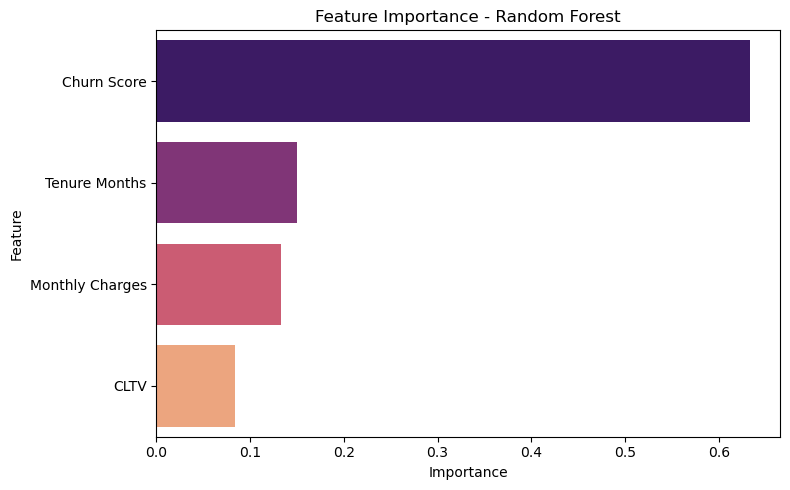

In [54]:
# feature importance
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_final.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nfeature importance：")
print(importance_df)


plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    legend=False,
    palette="magma"
)

plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

**build the model without churn score**

,k_folds,train_acc,val_acc,val_precision,val_recall,val_f1,val_auc
0,5,1.0,0.774763,0.604404,0.438127,0.507911,0.794131
1,10,1.0,0.778315,0.612090,0.451544,0.519284,0.794519
2,15,1.0,0.779202,0.614652,0.450249,0.519078,0.796417



📊 test set performance without churn score：
Accuracy: 0.7721788502484032
Precision: 0.5910652920962199
Recall: 0.45989304812834225
F1 Score: 0.5172932330827068
AUC: 0.7900785347076907

🌟 feature importance without churn score）：
           Feature  Importance
1  Monthly Charges    0.388702
2             CLTV    0.321013
0    Tenure Months    0.290285


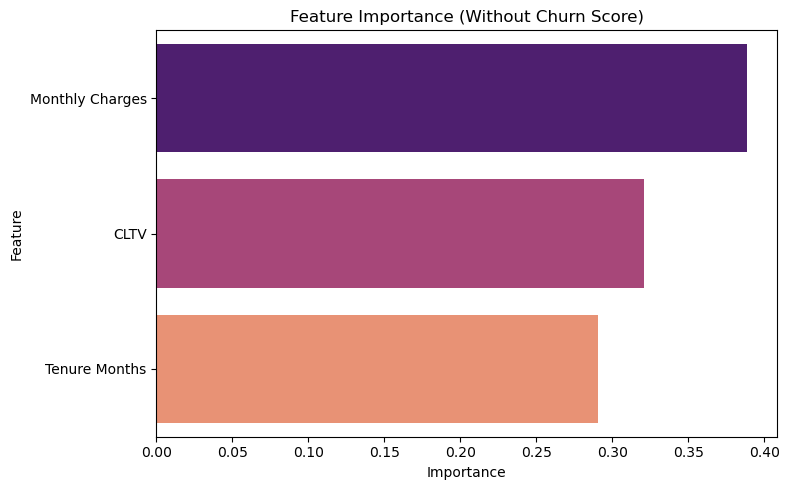

In [36]:
# Without Churn Score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# cross validation

k_values = [5, 10, 15]
cv_summary_rf = []

for k in k_values:
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_validate(
        rf_model,
        X_1_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        return_train_score=True
    )

    cv_summary_rf.append({
        "k_folds": k,
        "train_acc": scores["train_accuracy"].mean(),
        "val_acc": scores["test_accuracy"].mean(),
        "val_precision": scores["test_precision"].mean(),
        "val_recall": scores["test_recall"].mean(),
        "val_f1": scores["test_f1"].mean(),
        "val_auc": scores["test_roc_auc"].mean()
    })

cv_results_rf = pd.DataFrame(cv_summary_rf)
display(cv_results_rf)

# train model
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_1_train, y_train)

# final model
y_pred = rf_final.predict(X_1_test)
y_prob = rf_final.predict_proba(X_1_test)[:, 1]

print("\n📊 test set performance without churn score：")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

# feature importance
importance_df = pd.DataFrame({
    "Feature": X_1.columns,
    "Importance": rf_final.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n🌟 feature importance without churn score）：")
print(importance_df)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    legend=False,
    palette="magma"
)

plt.title("Feature Importance Without Churn Score")
plt.tight_layout()
plt.show()

**Hyperparameter Tuning using GridSearchCV for the model without churn score**

In [44]:
#hyperparameter tuning for the model without churn score
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 8, 10, 12],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_1_train, y_train)

print("best parameters：", grid_search_rf.best_params_)
print("bestCV AUC：", grid_search_rf.best_score_)



Fitting 5 folds for each of 216 candidates, totalling 1080 fits
best parameters： {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 100}
bestCV AUC： 0.8180112073121629


**final model evaluation without churn score on test set after hyperparameter tuning**


In [47]:
best_rf = grid_search_rf.best_estimator_

y_pred = best_rf.predict(X_1_test)
y_prob = best_rf.predict_proba(X_1_test)[:, 1]

print("\n📊 test set performance for the model without churn score after hyperparameter tuning：")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))


📊 test set performance for the model without churn score after hyperparameter tuning：
Accuracy: 0.7821149751596878
Precision: 0.6390041493775933
Recall: 0.4117647058823529
F1 Score: 0.5008130081300813
AUC: 0.8187643700431424


**3.3 XGBoost**

正在准备 XGBoost 数据...
原始特征维度: (7043, 4)
特征列： ['Tenure Months', 'Monthly Charges', 'Churn Score', 'CLTV']
数据类型：
Tenure Months        int64
Monthly Charges    float64
Churn Score          int64
CLTV                 int64
dtype: object

处理后的特征维度: (7043, 4)
处理后的特征列： ['Tenure Months', 'Monthly Charges', 'Churn Score', 'CLTV']
缺失值总数: 0

✅ X_train shape: (5634, 4)
✅ X_test shape: (1409, 4)
✅ X_train columns: ['Tenure Months', 'Monthly Charges', 'Churn Score', 'CLTV']
✅ y_train unique values: [0, 1]
✅ y_train dtype: int64

正在进行 XGBoost 交叉验证（with Churn Score）...

--- 正在跑 5-fold CV ---

--- 正在跑 10-fold CV ---

--- 正在跑 15-fold CV ---

✅ XGBoost 交叉验证结果（with Churn Score）：


,model_version,k_folds,train_accuracy_mean,train_accuracy_std,val_accuracy_mean,val_accuracy_std,val_precision_mean,val_precision_std,val_recall_mean,val_recall_std,val_f1_mean,val_f1_std,val_auc_mean,val_auc_std
0,with_churn_score,5,0.941427,0.003107,0.922791,0.008257,0.874398,0.024862,0.828763,0.014252,0.850770,0.014951,0.979732,0.004606
1,with_churn_score,10,0.939928,0.001561,0.924208,0.008749,0.879736,0.027813,0.828770,0.024228,0.853011,0.016631,0.980050,0.004581
2,with_churn_score,15,0.939678,0.001710,0.925275,0.013825,0.878269,0.032452,0.834774,0.029737,0.855672,0.026570,0.979829,0.006341



正在进行 XGBoost Grid Search 调参（with Churn Score），请稍候...
Fitting 5 folds for each of 64 candidates, totalling 320 fits

✅ XGBoost 调参完成（with Churn Score）！
最佳参数： {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
最佳交叉验证 AUC： 0.9803419389522163

正在训练最终 XGBoost 模型...

📊 测试集表现（Tuned XGBoost with Churn Score）：
Accuracy: 0.9268985095812633
Precision: 0.8712328767123287
Recall: 0.8502673796791443
F1 Score: 0.8606224627875507
AUC: 0.9796416853961611

🌟 XGBoost 特征重要性：
           Feature  Importance
2      Churn Score    0.771272
0    Tenure Months    0.129098
1  Monthly Charges    0.091814
3             CLTV    0.007815


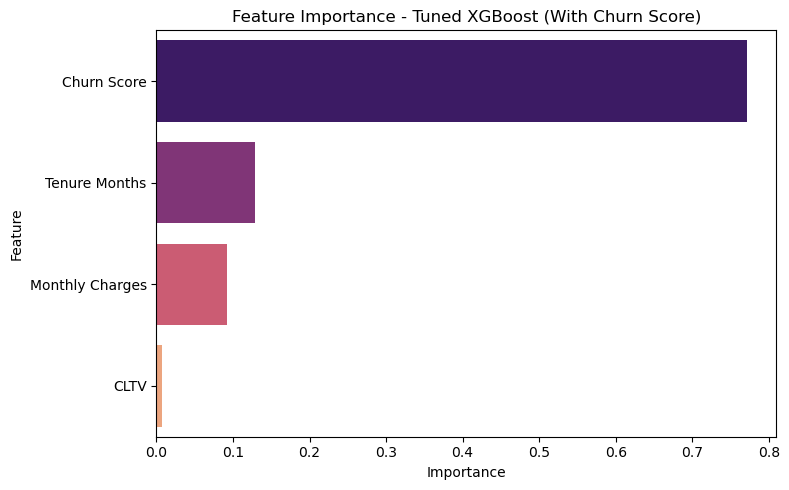

In [162]:
# ==========================================
# XGBoost 完整代码（指定自变量版本）
# X = ["Tenure Months", "Monthly Charges", "Churn Score", "CLTV"]
# ==========================================

# Step 0: 导入包
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# ==========================================
# Step 1: 数据准备
# ==========================================
print("正在准备 XGBoost 数据...")

y = df["Churn Value"].astype(int).copy()
feature_cols = ["Tenure Months", "Monthly Charges", "Churn Score", "CLTV"]
X = df[feature_cols].copy()

print("原始特征维度:", X.shape)
print("特征列：", X.columns.tolist())
print("数据类型：")
print(X.dtypes)

# 转数值型并处理缺失值
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median())

print("\n处理后的特征维度:", X.shape)
print("处理后的特征列：", X.columns.tolist())
print("缺失值总数:", X.isnull().sum().sum())

# 划分训练集 / 测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")
print("✅ X_train columns:", X_train.columns.tolist())
print(f"✅ y_train unique values: {sorted(y_train.unique())}")
print(f"✅ y_train dtype: {y_train.dtype}")


# ==========================================
# Step 2: 普通交叉验证
# ==========================================
print("\n正在进行 XGBoost 交叉验证（with Churn Score）...")

k_values = [5, 10, 15]
cv_summary_xgb = []

for k in k_values:
    print(f"\n--- 正在跑 {k}-fold CV ---")
    
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=1,
        eval_metric="logloss"
    )

    scores = cross_validate(
        xgb_model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        return_train_score=True,
        n_jobs=1,
        error_score="raise"
    )

    cv_summary_xgb.append({
        "model_version": "with_churn_score",
        "k_folds": k,
        "train_accuracy_mean": scores["train_accuracy"].mean(),
        "train_accuracy_std": scores["train_accuracy"].std(),
        "val_accuracy_mean": scores["test_accuracy"].mean(),
        "val_accuracy_std": scores["test_accuracy"].std(),
        "val_precision_mean": scores["test_precision"].mean(),
        "val_precision_std": scores["test_precision"].std(),
        "val_recall_mean": scores["test_recall"].mean(),
        "val_recall_std": scores["test_recall"].std(),
        "val_f1_mean": scores["test_f1"].mean(),
        "val_f1_std": scores["test_f1"].std(),
        "val_auc_mean": scores["test_roc_auc"].mean(),
        "val_auc_std": scores["test_roc_auc"].std()
    })

cv_results_xgb = pd.DataFrame(cv_summary_xgb)

print("\n✅ XGBoost 交叉验证结果（with Churn Score）：")
display(cv_results_xgb)


# ==========================================
# Step 3: Grid Search 调参（精简稳定版）
# ==========================================
print("\n正在进行 XGBoost Grid Search 调参（with Churn Score），请稍候...")

param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0, 0.1]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=1
)

grid_search_xgb_cs = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search_xgb_cs.fit(X_train, y_train)

print("\n✅ XGBoost 调参完成（with Churn Score）！")
print("最佳参数：", grid_search_xgb_cs.best_params_)
print("最佳交叉验证 AUC：", grid_search_xgb_cs.best_score_)


# ==========================================
# Step 4: 最终模型训练
# ==========================================
print("\n正在训练最终 XGBoost 模型...")

best_xgb_cs = grid_search_xgb_cs.best_estimator_
best_xgb_cs.fit(X_train, y_train)


# ==========================================
# Step 5: 测试集评估
# ==========================================
y_pred = best_xgb_cs.predict(X_test)
y_prob = best_xgb_cs.predict_proba(X_test)[:, 1]

print("\n📊 测试集表现（Tuned XGBoost with Churn Score）：")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))


# ==========================================
# Step 6: 特征重要性
# ==========================================
importance_df_xgb_cs = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb_cs.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n🌟 XGBoost 特征重要性：")
print(importance_df_xgb_cs)


# ==========================================
# Step 7: 可视化
# ==========================================
plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance_df_xgb_cs,
    x="Importance",
    y="Feature",
    hue="Feature",
    legend=False,
    palette="magma"
)

plt.title("Feature Importance - Tuned XGBoost (With Churn Score)")
plt.tight_layout()
plt.show()

正在准备 XGBoost 数据（without Churn Score）...
特征列： ['Tenure Months', 'Monthly Charges', 'CLTV']
数据维度： (7043, 3)
✅ X_train: (5634, 3)
✅ X_test: (1409, 3)

正在进行交叉验证...

--- 5-fold CV ---

--- 10-fold CV ---

--- 15-fold CV ---

CV结果：
    k  train_auc   val_auc
0   5   0.872850  0.815781
1  10   0.868601  0.817640
2  15   0.867307  0.817799

正在调参...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
最佳参数： {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
最佳CV AUC： 0.8197913179962196

📊 测试集表现（without Churn Score）：
Accuracy: 0.7885024840312278
Precision: 0.6472868217054264
Recall: 0.446524064171123
F1: 0.5284810126582279
AUC: 0.8244348859438373

🌟 特征重要性：
           Feature  Importance
0    Tenure Months    0.543450
1  Monthly Charges    0.411969
2             CLTV    0.044581


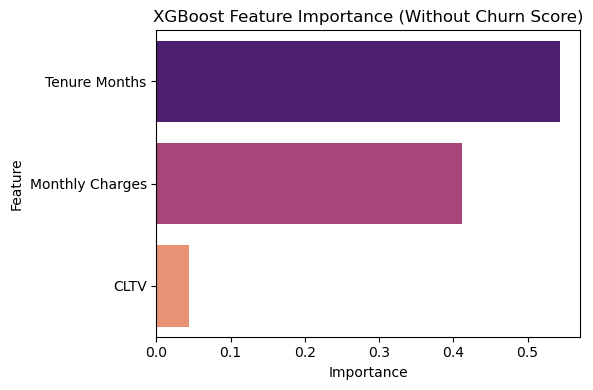

In [166]:
# ==========================================
# Step 0: 导入包
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# ==========================================
# Step 1: 数据准备（只用3个数值变量）
# ==========================================
print("正在准备 XGBoost 数据（without Churn Score）...")

y = df["Churn Value"].astype(int)
X = df[["Tenure Months", "Monthly Charges", "CLTV"]]

print("特征列：", X.columns.tolist())
print("数据维度：", X.shape)

# 划分训练 / 测试
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ X_train: {X_train.shape}")
print(f"✅ X_test: {X_test.shape}")


# ==========================================
# Step 2: 交叉验证
# ==========================================
print("\n正在进行交叉验证...")

k_values = [5, 10, 15]
cv_summary = []

for k in k_values:
    print(f"\n--- {k}-fold CV ---")

    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=1
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        return_train_score=True,
        n_jobs=1
    )

    cv_summary.append({
        "k": k,
        "train_auc": scores["train_roc_auc"].mean(),
        "val_auc": scores["test_roc_auc"].mean()
    })

cv_results = pd.DataFrame(cv_summary)
print("\nCV结果：")
print(cv_results)


# ==========================================
# Step 3: Grid Search 调参
# ==========================================
print("\n正在调参...")

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=1),
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("最佳参数：", grid.best_params_)
print("最佳CV AUC：", grid.best_score_)


# ==========================================
# Step 4: 最终模型
# ==========================================
best_xgb = grid.best_estimator_
best_xgb.fit(X_train, y_train)


# ==========================================
# Step 5: 测试集评估
# ==========================================
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print("\n📊 测试集表现（without Churn Score）：")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))


# ==========================================
# Step 6: 特征重要性
# ==========================================
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n🌟 特征重要性：")
print(importance_df)


# ==========================================
# Step 7: 可视化
# ==========================================
plt.figure(figsize=(6,4))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    legend=False,
    palette="magma"
)

plt.title("XGBoost Feature Importance (Without Churn Score)")
plt.tight_layout()
plt.show()

## 5. Q&A

**Q: For the high churn rate among month-to-month users, what do you think would be the most effective intervention strategy?**

A: The most effective strategy is to increase their switching costs by offering discounts or bundled services to incentivize signing a one-year contract. Crucially, we will use our model to cross-reference Churn Score and CLTV, ensuring we only target these retention efforts toward high-risk, high-value customers.

**Q: If the prediction model has high accuracy but low recall, how would that impact customer retention efforts and how would you address it?**

A: High accuracy with low recall means the model misses many actual churners, causing the company to lose revenue because these at-risk customers slip away without receiving any retention offers. To address this, we would lower the prediction threshold to capture more potential churners, apply class weights to heavily penalize false negatives.

**Q: Considering that customer behavior evolves over time, did you look into the issue of 'Concept Drift'? How often would you recommend retraining the model to maintain its predictive accuracy in a changing market?**

A: To ensure the model adapts to evolving customer behaviors and market conditions, we recommend a dual approach: scheduling regular model retraining on a quarterly basis using the latest data, and implementing continuous monitoring of key metrics like recall and precision to automatically trigger an immediate retraining cycle if performance drops below a predefined acceptable threshold.

**Q: Once all work is complete, what level of performance does your team anticipate achieving? Furthermore, I would be very interested to learn what commonalities exist between your model and the current state-of-the-art models.**

A: We anticipate achieving an ROC-AUC score above 0.85 and a highly optimized recall rate to ensure we capture the vast majority of at-risk customers.

**Q: Which factors were the most important for predicting churn?**

A: Based on our analysis, the most critical factors for predicting churn are contract terms, customer longevity, and financial metrics. Contract Type is the strongest predictor, with month-to-month users showing the highest churn risk. Tenure Months is also heavily weighted, as newer customers are far more likely to leave than long-term veterans. Additionally, high Monthly Charges, particularly when interacting with specific services like Fiber Optic internet, strongly signal churn risk, making these three features the core drivers of our predictive model.

**Q: Will the handling of missing values and in the preprocessing stage affect the performance and bias of the model?**

A: Yes, absolutely. How you handle missing values directly impacts both performance and bias.

**Q: What is the target of Hyperparameter Optimization?**

A: The primary target of hyperparameter optimization is to find the optimal combination of model settings (which are not learned from the data itself) to maximize the model's performance on unseen data.

**Q: Is your dataset imbalanced?**

A: Yes, the dataset is inherently imbalanced, which is typical for real-world scenarios where the majority of customers stay and only a smaller percentage actually churn.

**Q: From the plots across different features, it is difficult to identify clear relationships with churn. Could you elaborate on how the data preprocessing and cleaning steps could be improved to better reveal these patterns?**

A: That is a great observation. The lack of clear linear patterns in the raw data highlights the absolute necessity of advanced feature engineering.